# Banded Bathymetry Example

`bathymetry_method="banded"` fills discrete depth bands with explicit colors (deepest to
shallowest), plus draws the usual isobath lines/labels and a color-swatch legend. This
notebook walks through:

1. The default banded bathymetry, with its legend on.
2. The same map with the legend turned off.
3. The default bathymetry with fake data overlaid (synthetic Argo float surfacing points),
   demonstrating **how to have two independent legends on the same axes** -- one for the
   bathymetry bands, one for the overlaid points.
4. The same overlay, but with the bathymetry legend moved to the lower right (inside the
   map) and the Argo legend moved outside the map entirely, showing that each legend's
   position is fully independent of the other.


---
## Setup


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import cool_maps.plot as cplt

# Gulf of Mexico
extent = [-99, -79, 18, 31]


---
## 1. Default banded bathymetry, legend on

`bathymetry_method="banded"` works with no extra configuration: the default
`isobaths=(-1000, -100)` produce exactly 3 depth bands, which have a built-in default color
scheme (the middle band matches cool_maps' usual ocean color). The legend defaults to
meters only (unlike `shadedcontour`, which defaults to meters + fathoms).


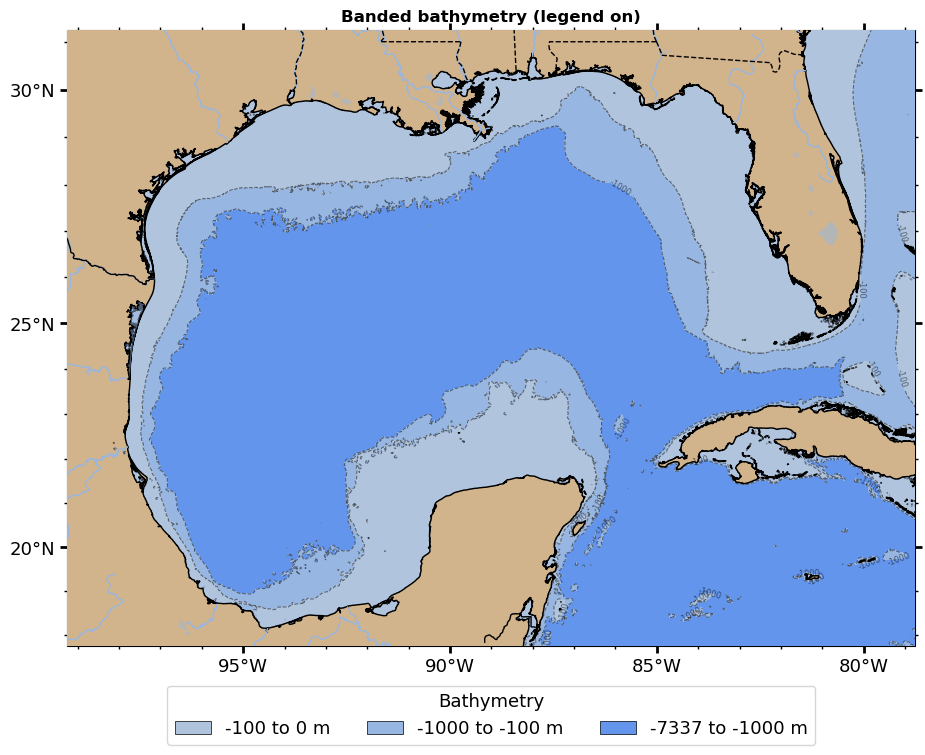

In [2]:
fig, ax = cplt.create(extent, bathymetry=True, bathymetry_method="banded")
ax.set_title("Banded bathymetry (legend on)", fontweight="bold")
plt.show()


---
## 2. Default banded bathymetry, legend off

Pass `bathymetry_legend_scale="off"` (via `create()`) -- or `legend_scale="off"` if calling
`add_bathymetry()` directly -- to drop the legend entirely.


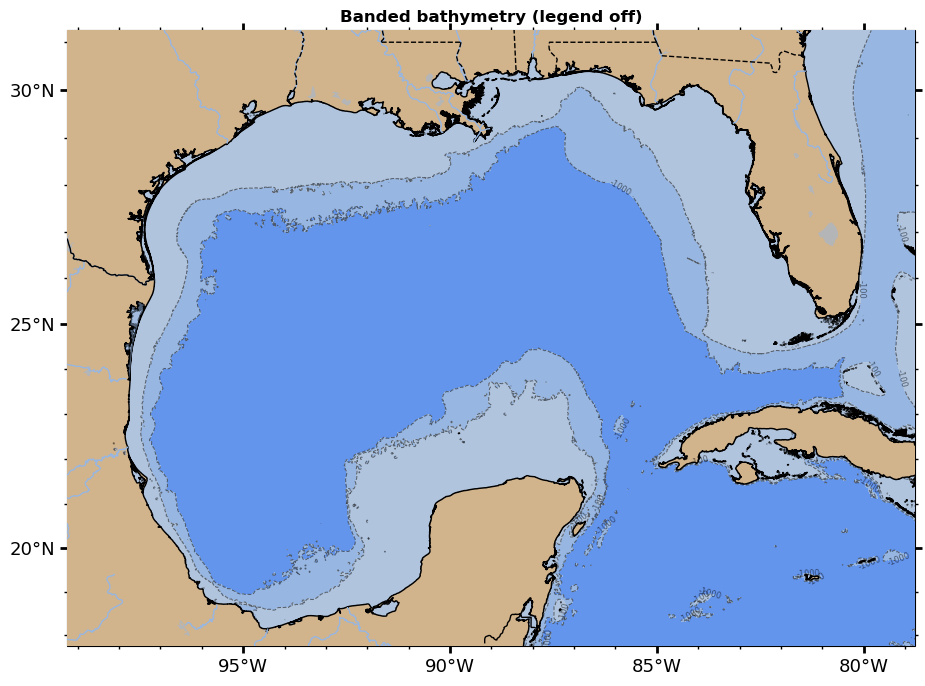

In [3]:
fig, ax = cplt.create(
    extent,
    bathymetry=True,
    bathymetry_method="banded",
    bathymetry_legend_scale="off",
)
ax.set_title("Banded bathymetry (legend off)", fontweight="bold")
plt.show()


---
## 3. Overlaying data with two legends

Matplotlib only keeps *one* "current" legend per axes by default -- calling `ax.legend()` a
second time replaces the first one instead of adding to it. `cplt.add_legend(ax, ...)` is a
drop-in replacement for `ax.legend(...)` that preserves whatever legend is already there
before creating the new one, so you can call it repeatedly to build up any number of
legends on the same axes.

Under the hood, `add_legend()` takes care of two non-obvious things so you don't have to:

1. Preserving the old legend the "normal" way (`ax.get_legend()` + `ax.add_artist()`) also
   clips it to the axes' rectangular patch, since `add_artist()` clips any artist that
   doesn't already have a clip path set. That's fatal for legends positioned outside the
   axes (like cool_maps' own bathymetry legend, which sits below the map) -- it would
   render completely invisible, not just cut off. `add_legend()` turns clipping back off
   for you.
2. It's still up to you to keep each legend's `zorder` above cool_maps' land/feature layers
   (`zorder` ~10-10.3, see `add_features()`) if you place it somewhere inside the map --
   otherwise land can silently paint over it, as it would for "upper left" on this
   particular extent (that corner is the Texas/Louisiana coast, not open water).


In [6]:
# Fake Argo float surfacing locations
rng = np.random.default_rng(7)
n_floats = 8
argo_lon = rng.uniform(-96, -82, n_floats)
argo_lat = rng.uniform(20, 29, n_floats)


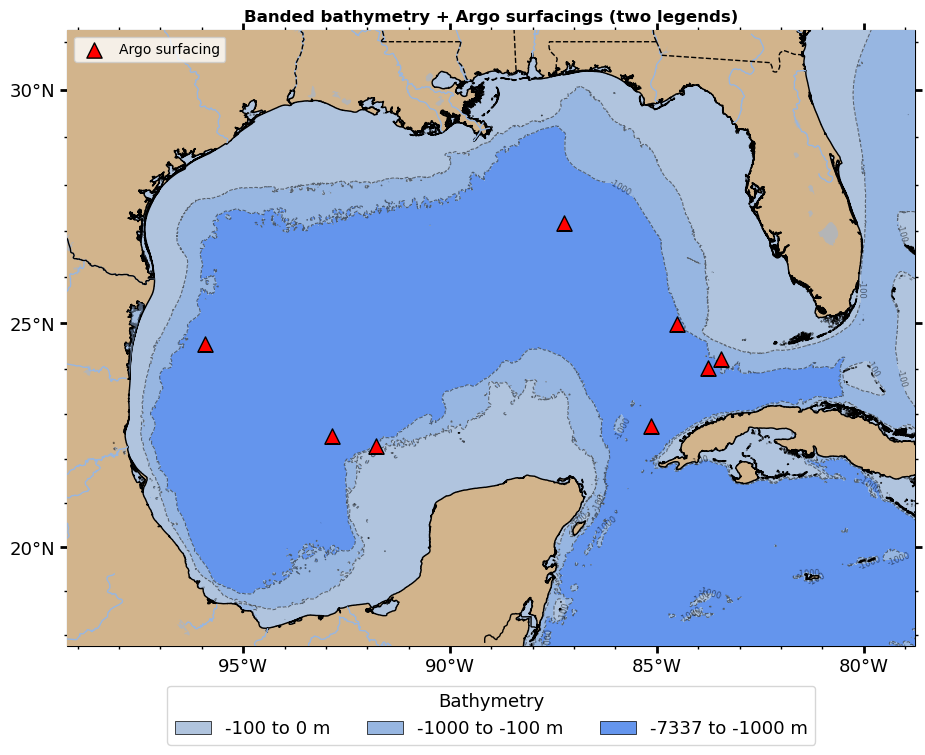

In [7]:
fig, ax = cplt.create(extent, bathymetry=True, bathymetry_method="banded")

argo_scatter = ax.scatter(
    argo_lon, argo_lat,
    marker="^", color="red", edgecolor="black", s=120, zorder=250,
    label="Argo surfacing",
)
argo_legend = cplt.add_legend(ax, handles=[argo_scatter], loc="upper left", fontsize=10)
argo_legend.set_zorder(250)  # keep it above cool_maps' land/feature layers (zorder ~10-10.3)

ax.set_title("Banded bathymetry + Argo surfacings (two legends)", fontweight="bold")
plt.show()


Both legends are independent `Legend` artists on the same axes: the bathymetry legend
stays anchored below the map (its original position), and the Argo legend sits inside the
map at the upper left, so they don't overlap.


---
## 4. Custom legend positions

Each legend's position is independent of the others -- put the bathymetry legend in the
lower right *inside* the map, and the Argo legend *outside* the map entirely, off to the
right.

To move the bathymetry legend, grab its handles/labels from the one `create()` already
built, remove it, and rebuild it wherever you want with `add_legend()`. To place a legend
outside the axes, anchor it just past the edge of the axes in axes-fraction coordinates
with `bbox_to_anchor` -- `(1.02, 1)` means "just to the right of x=1 (the axes' right
edge), aligned with y=1 (the top)".


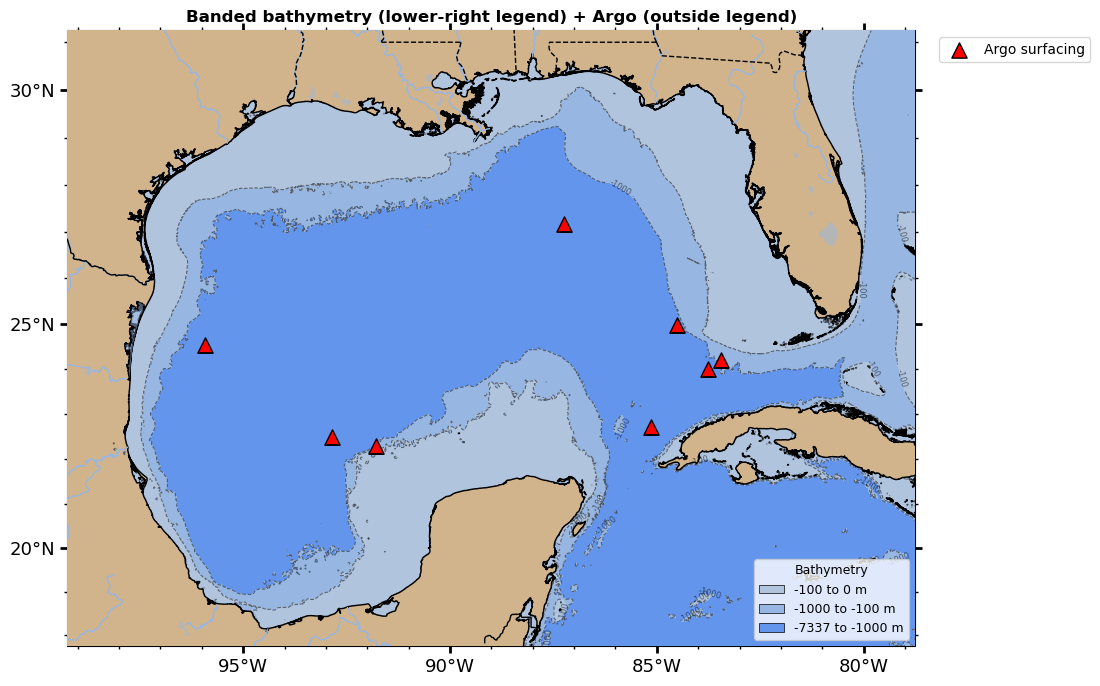

In [ ]:
fig, ax = cplt.create(extent, bathymetry=True, bathymetry_method="banded")

# Move the auto-built bathymetry legend to the lower right, inside the map. Grab its
# title too -- rebuilding from handles/labels alone doesn't carry it over.
old_bathy_legend = ax.get_legend()
bathy_handles = old_bathy_legend.legend_handles
bathy_labels = [t.get_text() for t in old_bathy_legend.get_texts()]
bathy_title = old_bathy_legend.get_title().get_text()
old_bathy_legend.remove()

bathy_legend = cplt.add_legend(
    ax, handles=bathy_handles, labels=bathy_labels, title=bathy_title,
    loc="lower right", fontsize=9, title_fontsize=9,
)
bathy_legend.set_zorder(240)  # this corner is open water for this extent, but stay safe anyway

# Put the Argo legend outside the map entirely, to the right.
argo_scatter = ax.scatter(
    argo_lon, argo_lat,
    marker="^", color="red", edgecolor="black", s=120, zorder=250,
    label="Argo surfacing",
)
argo_legend = cplt.add_legend(ax, handles=[argo_scatter], loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
argo_legend.set_zorder(250)

ax.set_title("Banded bathymetry (lower-right legend) + Argo (outside legend)", fontweight="bold")
plt.show()
